# Notebook C of line ratios from saved maps from the PZ cube

This is from the splitting up of ZZ-01-01-more-line-ratios.ipynb. It includes analysis of the He I and He II lines

In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from mpdaf.obj import Image
import regions
import sys
import pandas as pd
import cmasher as cmr
import pyneb as pn

sns.set_context("talk")
sns.set_color_codes()

/Users/will/Dropbox/muse-hii-regions/.venv/lib/python3.14/site-packages/mpdaf/version.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Path to the root of this repo

In [2]:
ROOT = Path.cwd().parent.parent

In [3]:
mapspath = ROOT / "data/n346-bow-lines/refined"

In [4]:
def get_image(lineid, combo="P-007", ext="SUM"):
    im = Image(str(mapspath / f"map-{lineid}-{combo}.fits"), ext=ext)
    im.data = im.data.astype(float)
    return im


def get_image_raw(lineid, variant="csub", channel="ABC"):
    p = ROOT / "data" / "n346-bow-lines" / f"maps-n346-PZ-2pass-{variant}-007"
    candidates = list(p.glob(f"**/*-{lineid}-{channel}.fits"))
    assert candidates
    imfile = candidates[0]
    im = Image(str(imfile))
    im.data = im.data.astype(float)
    return im

## Reddening law for SMC

In [5]:
rc = pn.RedCorr()
rc.R_V = 2.74
rc.FitzParams = [-4.96, 2.26, 0.39, 0.6, 4.6, 1.0]
rc.law = "F99"

## Calculate He I / Hβ

Let us see if this has a hole in it where the He II is coming from.
+

In [118]:
im5875 = get_image_raw("he-i-5875-62")
im4922 = get_image_raw("he-i-4921-93")
im5048 = get_image_raw("he-i-5047-74")
im5016 = get_image_raw("he-i-5015-68")
im6678 = get_image_raw("he-i-6678-15")
im7065 = get_image_raw("he-i-7065-28")
im7281 = get_image_raw("he-i-7281-35")
imcont = get_image_raw("he-i-5875-62", variant="cont")
ew5875 = 3 * 1.25 * im5875 / imcont
imhb = get_image_raw("h-i-4861-32")
imha = get_image_raw("h-i-656*")

Text(0.5, 1.0, 'He I 7065')

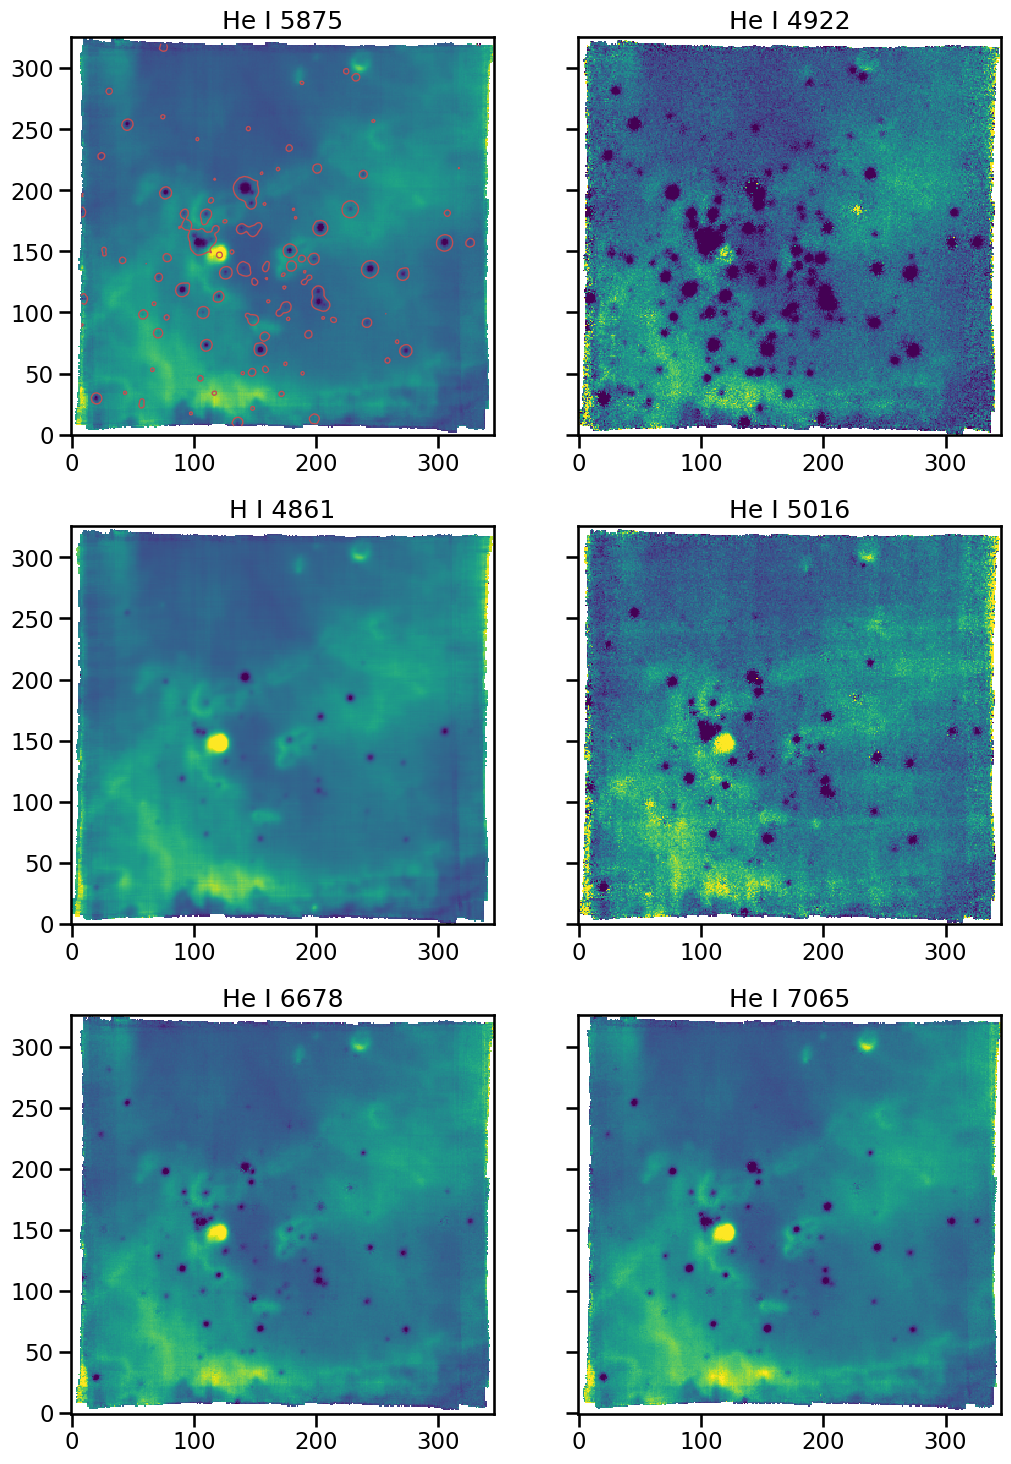

In [124]:
fig, axes = plt.subplots(3, 2, sharey=True, figsize=(12, 18))
im5875.plot(ax=axes[0, 0], vmin=0, vmax=7500)
axes[0, 0].contour(ew5875.data, levels=[3], colors="r", linewidths=1)
im4922.plot(ax=axes[0, 1], vmin=0, vmax=550)
(imhb).plot(ax=axes[1, 0], vmin=0, vmax=60000)
im5016.plot(ax=axes[1, 1], vmin=0, vmax=700)
im6678.plot(ax=axes[2, 0], vmin=0, vmax=2000)
im7065.plot(ax=axes[2, 1], vmin=0, vmax=1400)
axes[0, 0].set_title("He I 5875")
axes[0, 1].set_title("He I 4922")
axes[1, 0].set_title("H I 4861")
axes[1, 1].set_title("He I 5016")
axes[2, 0].set_title("He I 6678")
axes[2, 1].set_title("He I 7065")

So 5875 is 10 to 100 times brighter than the other two. And it is almost identical to Hβ!

Text(0.5, 0.98, 'Correlation between Hβ 4861 and He I 5875 brightness')

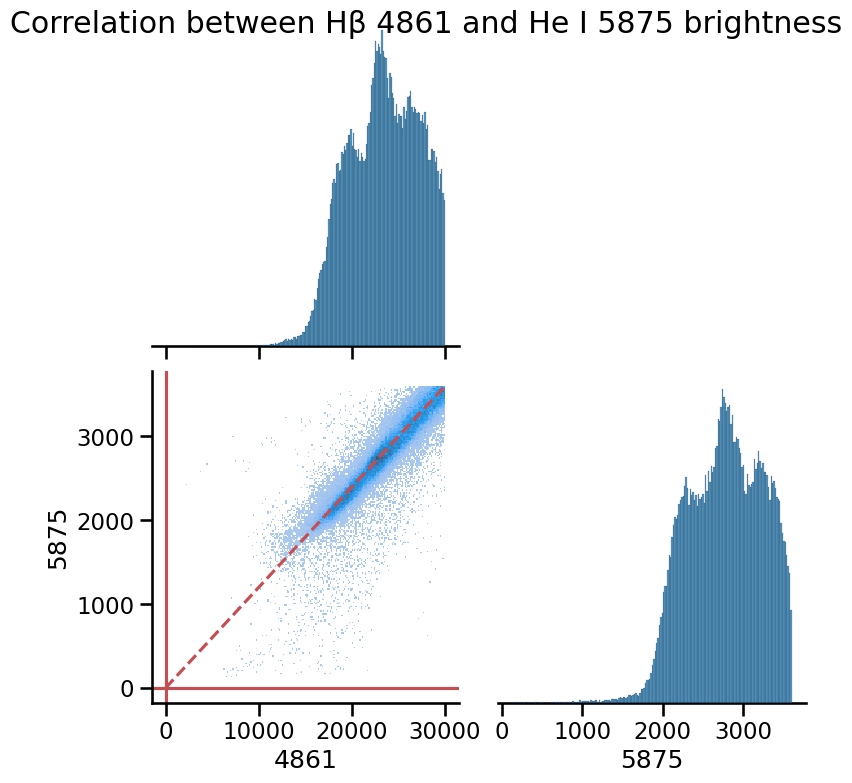

In [8]:
imax = 30000
imin = 1000
slope = 0.12
x = imhb.data
y = im5875.data
m = x < imax
m = m & (x > imin)
m = m & (y < slope * imax)
m = m & (y > imin * slope)
m = m & ~imhb.mask & ~im5875.mask
df = pd.DataFrame(
    {
        "4861": x[m],
        "5875": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(weights=x[m], bins=200),
    diag_kws=dict(weights=x[m], bins=200),
)
g.axes[1, 0].axvline(0.0, color="r")
g.axes[1, 0].axhline(0.0, color="r")
g.axes[1, 0].plot([0, imax], [0, slope * imax], "--", color="r")
g.fig.suptitle("Correlation between Hβ 4861 and He I 5875 brightness")

Text(0.5, 0.98, 'Correlation between Hβ 4861 and He I 5875 brightness')

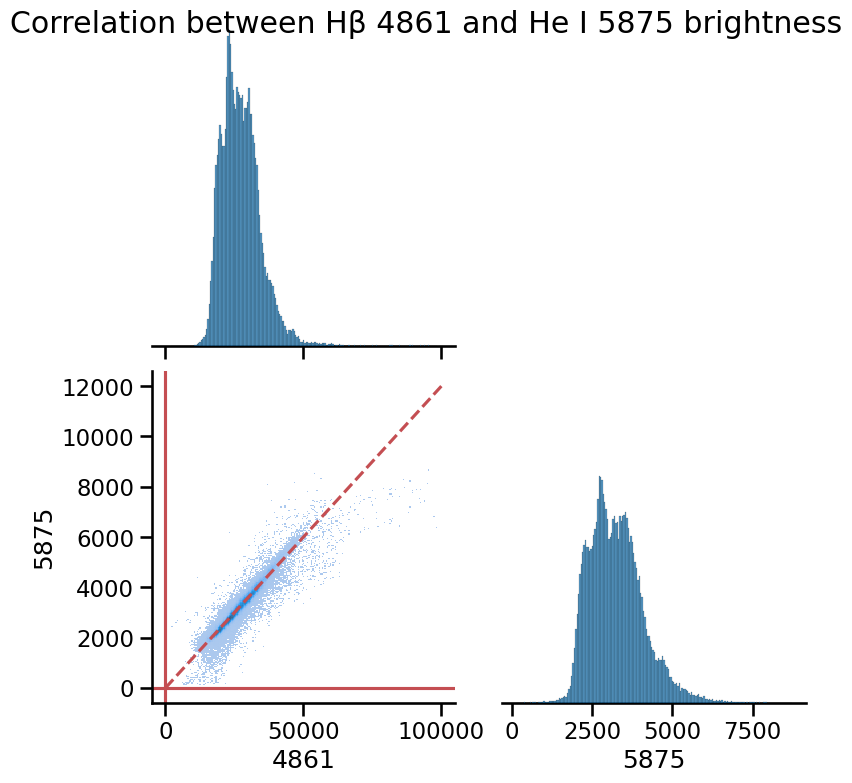

In [9]:
imax = 100000
imin = 1000
slope = 0.12
x = imhb.data
y = im5875.data
m = x < imax
m = m & (x > imin)
m = m & (y < slope * imax)
m = m & (y > imin * slope)
m = m & ~imhb.mask & ~im5875.mask
df = pd.DataFrame(
    {
        "4861": x[m],
        "5875": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(weights=x[m], bins=200),
    diag_kws=dict(weights=x[m], bins=200),
)
g.axes[1, 0].axvline(0.0, color="r")
g.axes[1, 0].axhline(0.0, color="r")
g.axes[1, 0].plot([0, imax], [0, slope * imax], "--", color="r")
g.fig.suptitle("Correlation between Hβ 4861 and He I 5875 brightness")

In [10]:
imEBV = Image(str(ROOT / "data/ngc346-ZZ-reddening-E_BV.fits"))

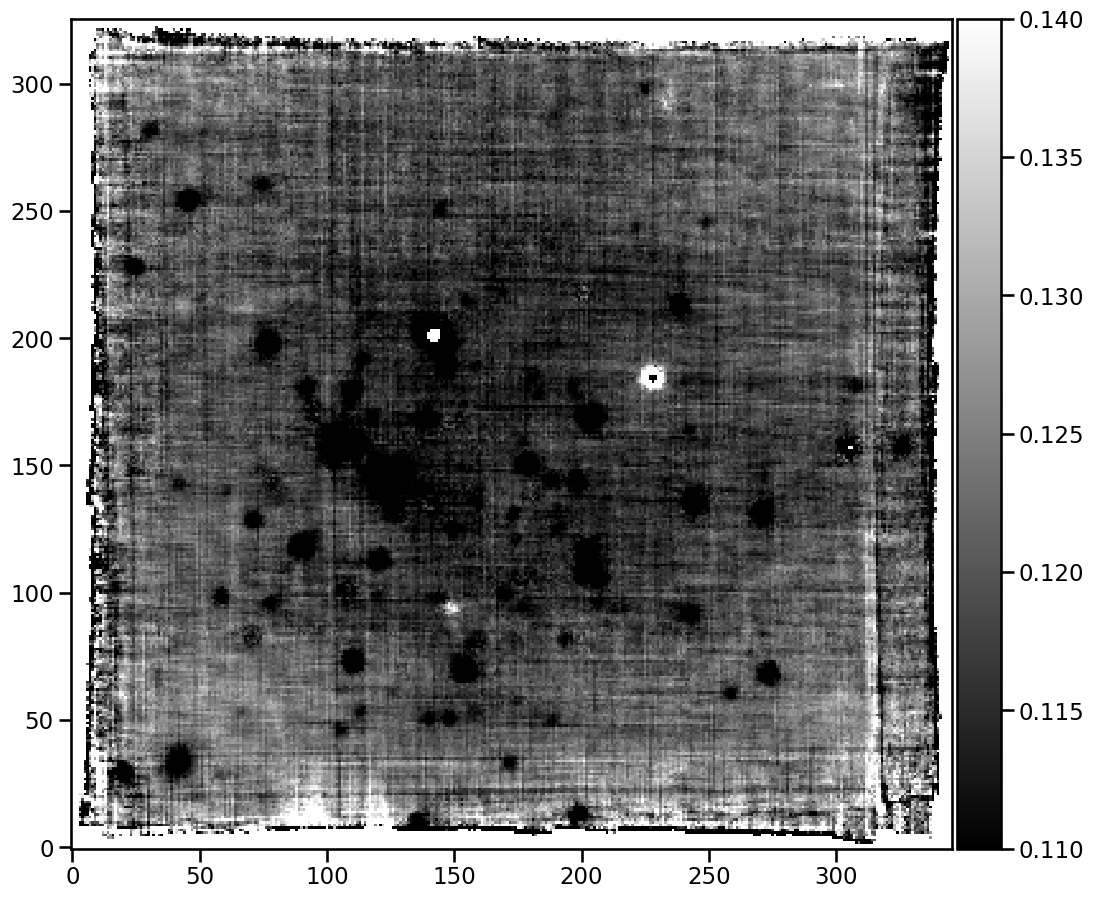

In [11]:
imR_hei_hb = im5875 / (imhb)

fig, ax = plt.subplots(figsize=(12, 12))
imR_hei_hb.plot(colorbar="v", cmap="gray", vmin=0.11, vmax=0.14)

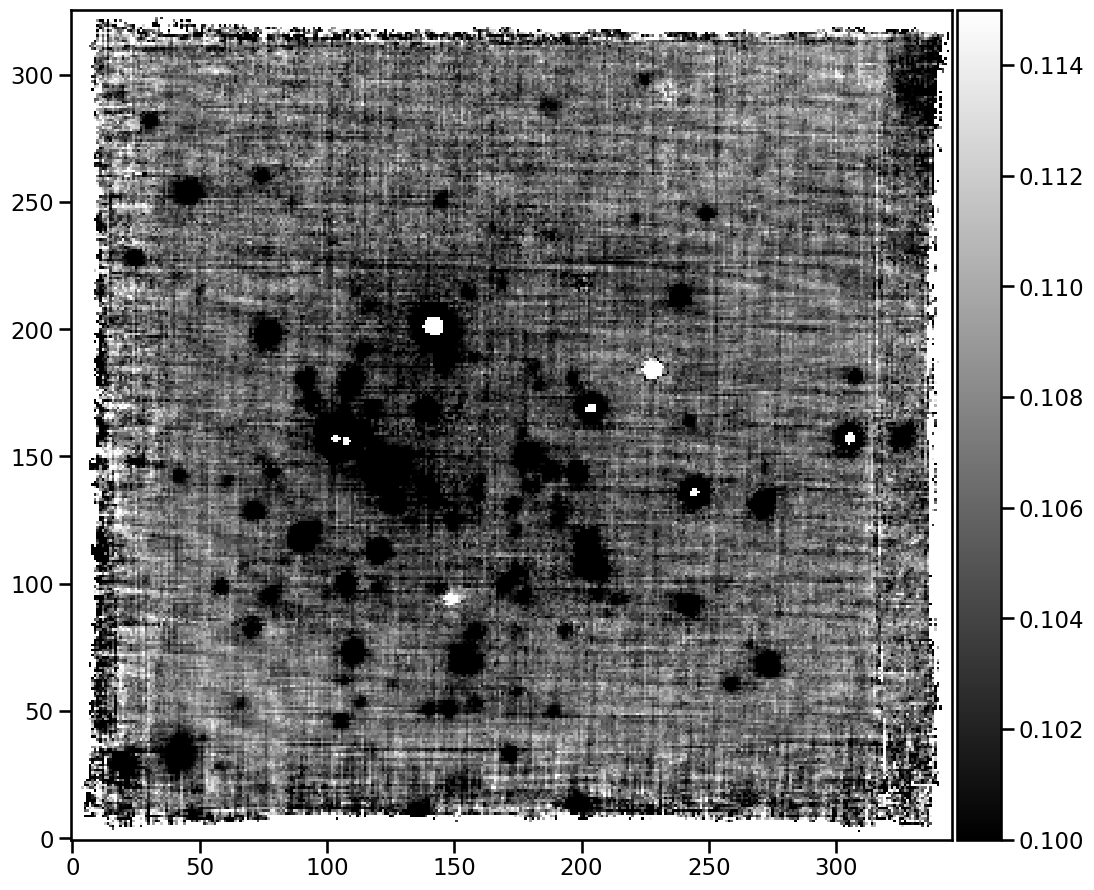

In [12]:
red_R_hei_hb = imR_hei_hb.copy()
red_R_hei_hb.data = 10 ** (0.4 * imEBV.data * (rc.X(4861) - rc.X(5875)))

fig, ax = plt.subplots(figsize=(12, 12))
(imR_hei_hb / red_R_hei_hb).plot(colorbar="v", cmap="gray", vmin=0.1, vmax=0.115)

So if we correct it for reddening, then lots of spurious structure disappears.  But we are left with very little variation at all, except for at the mYSO and the top right corner, which both show low He I.

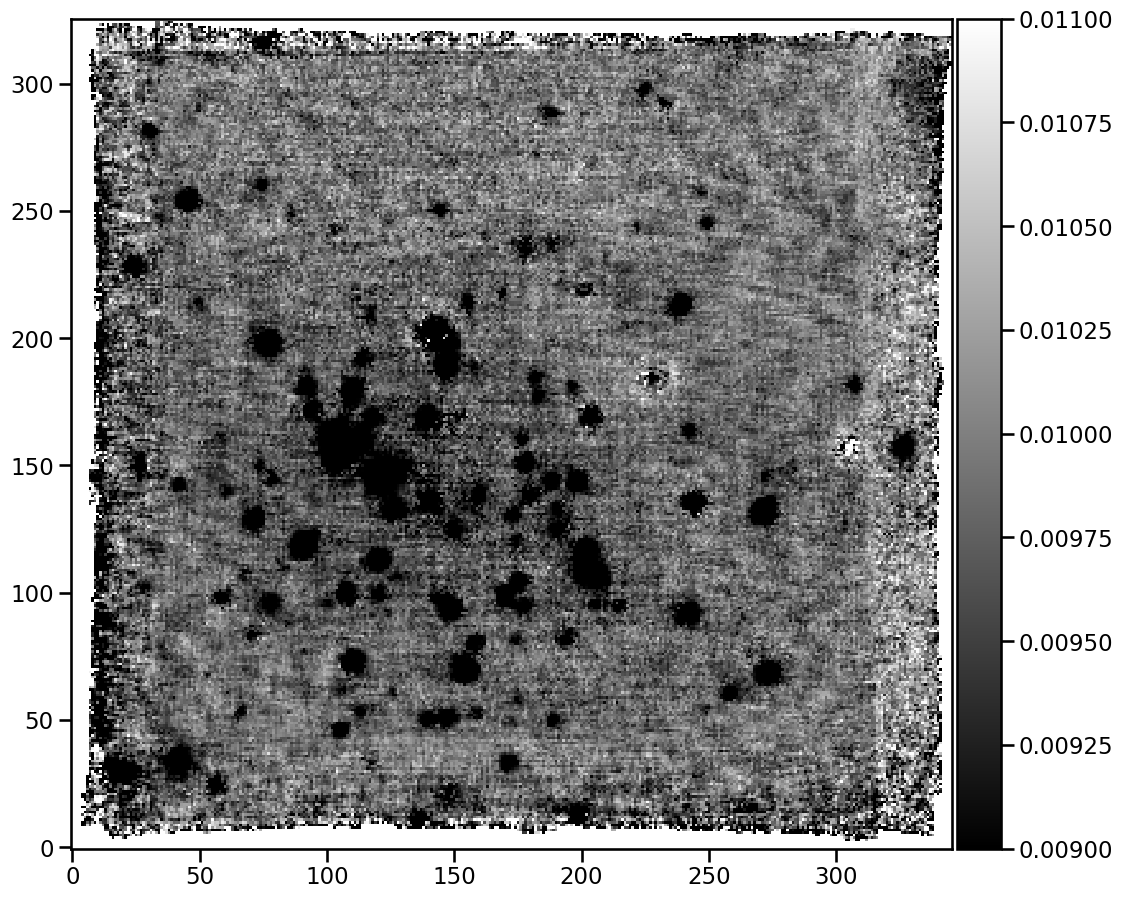

In [52]:
fig, ax = plt.subplots(figsize=(12, 12))
(im6678 / imha).plot(colorbar="v", cmap="gray", vmin=0.009, vmax=0.011)

In [57]:
1/3.5

0.2857142857142857

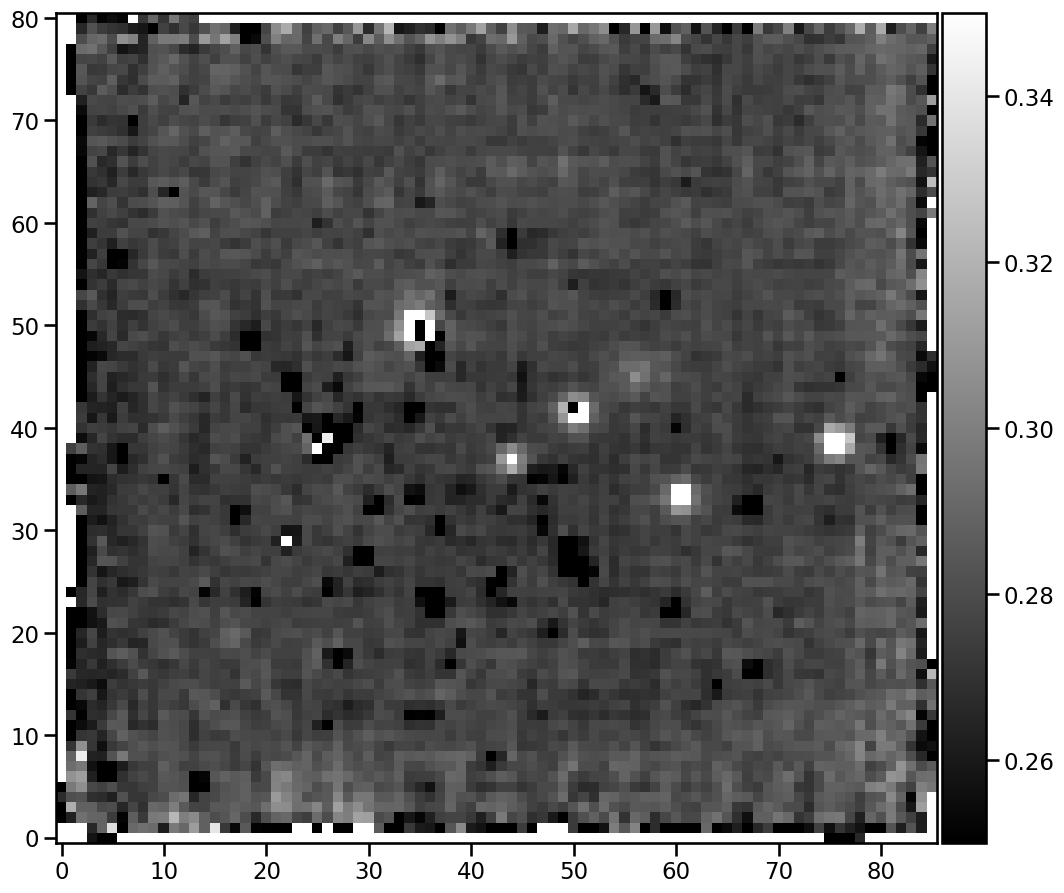

In [59]:
fig, ax = plt.subplots(figsize=(12, 12))
n = 4
(im6678.rebin(n) / im5875.rebin(n)).plot(colorbar="v", cmap="gray", vmin=0.25, vmax=0.35)

### He I emissivities

In [13]:
hei = pn.RecAtom("He", 1)

dens = [10, 50, 100, 200, 400, 800]
tems = [11000, 13000, 15000, 18000]
e4713 = hei.getEmissivity(tems, dens, wave=4713)
e4921 = hei.getEmissivity(tems, dens, wave=4922)
e5016 = hei.getEmissivity(tems, dens, wave=5016)
e5047 = hei.getEmissivity(tems, dens, wave=5047)
e5876 = hei.getEmissivity(tems, dens, wave=5876)
e6678 = hei.getEmissivity(tems, dens, wave=6678)
e7065 = hei.getEmissivity(tems, dens, wave=7065)
e7281 = hei.getEmissivity(tems, dens, wave=7281)

In [14]:
np.round(e5016 / e5876, 3)

array([[0.217, 0.217, 0.217, 0.215, 0.214, 0.212],
       [0.229, 0.228, 0.228, 0.224, 0.221, 0.217],
       [0.239, 0.238, 0.237, 0.23 , 0.224, 0.219],
       [0.253, 0.249, 0.248, 0.236, 0.227, 0.218]])

So 5016/5876 is a T indicator for low densities (becomes insensitive at high densities). 

At 50 pcc it is +15% with T

In [15]:
np.round(e5876 / e6678, 3)

array([[3.521, 3.522, 3.523, 3.526, 3.529, 3.532],
       [3.53 , 3.53 , 3.53 , 3.531, 3.533, 3.534],
       [3.538, 3.535, 3.534, 3.531, 3.528, 3.525],
       [3.548, 3.539, 3.535, 3.521, 3.508, 3.498]])

5876 / 6678 is flat with n (+0.3% at low-T, -1.4% at high-T) and flat with n (+0.5% at n=50)

In [16]:
np.round((e7281 + e7065) / e6678, 3)

array([[0.828, 0.847, 0.855, 0.912, 0.966, 1.018],
       [0.91 , 0.935, 0.946, 1.02 , 1.089, 1.153],
       [0.989, 1.018, 1.031, 1.114, 1.188, 1.256],
       [1.102, 1.133, 1.145, 1.226, 1.294, 1.352]])

So (7281 + 7065) / 6678 has positive variation with T (30%) and n (20%)

In [60]:
np.round(e7065 / e6678, 3)

array([[0.634, 0.651, 0.659, 0.711, 0.761, 0.81 ],
       [0.698, 0.722, 0.732, 0.801, 0.866, 0.927],
       [0.759, 0.788, 0.8  , 0.88 , 0.952, 1.017],
       [0.848, 0.88 , 0.892, 0.975, 1.044, 1.103]])

Just 7065/6678 is positive with T (+37%) and n (+32%)

In [80]:
np.round(e7065 / e7281, 3)

array([[3.267, 3.327, 3.352, 3.541, 3.717, 3.881],
       [3.292, 3.375, 3.41 , 3.66 , 3.885, 4.089],
       [3.315, 3.419, 3.462, 3.759, 4.02 , 4.251],
       [3.346, 3.476, 3.529, 3.875, 4.169, 4.422]])

7065 / 7281 is flattish with T (+5%) and positive with density (+24%)

In [83]:
np.round(e7281 / e6678, 3)

array([[0.194, 0.196, 0.197, 0.201, 0.205, 0.209],
       [0.212, 0.214, 0.215, 0.219, 0.223, 0.227],
       [0.229, 0.23 , 0.231, 0.234, 0.237, 0.239],
       [0.253, 0.253, 0.253, 0.251, 0.25 , 0.249]])

7281 / 6678 is flattish with n (+7%) and positive with temperature (+29%)

In [85]:
100 * (253 - 196)/196

29.081632653061224

In [17]:
np.round(e4713 / e5876, 3)

array([[0.04 , 0.04 , 0.041, 0.041, 0.042, 0.042],
       [0.045, 0.045, 0.045, 0.046, 0.046, 0.047],
       [0.049, 0.05 , 0.05 , 0.05 , 0.05 , 0.051],
       [0.056, 0.056, 0.056, 0.056, 0.056, 0.056]])

4713 / 5876 is too weak

In [18]:
np.round(e4921/ e5876, 3)

array([[0.099, 0.099, 0.099, 0.098, 0.097, 0.096],
       [0.1  , 0.1  , 0.1  , 0.098, 0.096, 0.095],
       [0.101, 0.101, 0.1  , 0.098, 0.095, 0.093],
       [0.103, 0.101, 0.101, 0.096, 0.093, 0.09 ]])

4921/5876 is rather weak too and not very sensitive: +2% with T at 50pcc, -5% with n at 13,000 K

#### Conclusions on He I ratios

* 5016/5876 is a reasonable T indicator (for densities < 500 pcc) *but it is much lower than predicted – maybe radiative transfer effects?*
* 7065/7281 is a possible density indicator
* 7281/6678 is a possible T indicator

But we need to do reddening correction for all of them. 

In [69]:
_ebv = imEBV.data[np.isfinite(imEBV.data)]

np.mean(_ebv), np.std(_ebv), np.median(_ebv), np.median(np.abs(_ebv - np.median(_ebv)))

(0.1660578645991401,
 0.05751530631173145,
 0.15584751963615417,
 0.0236750990152359)

In [87]:
10 ** (0.4 * 0.156 * (rc.X(7065) - rc.X(7281))), 10 ** (0.4 * 0.156 * (rc.X(7281) - rc.X(6678)))

(1.0123928764365902, 0.963769759088287)

### He I n-sensitive ratio



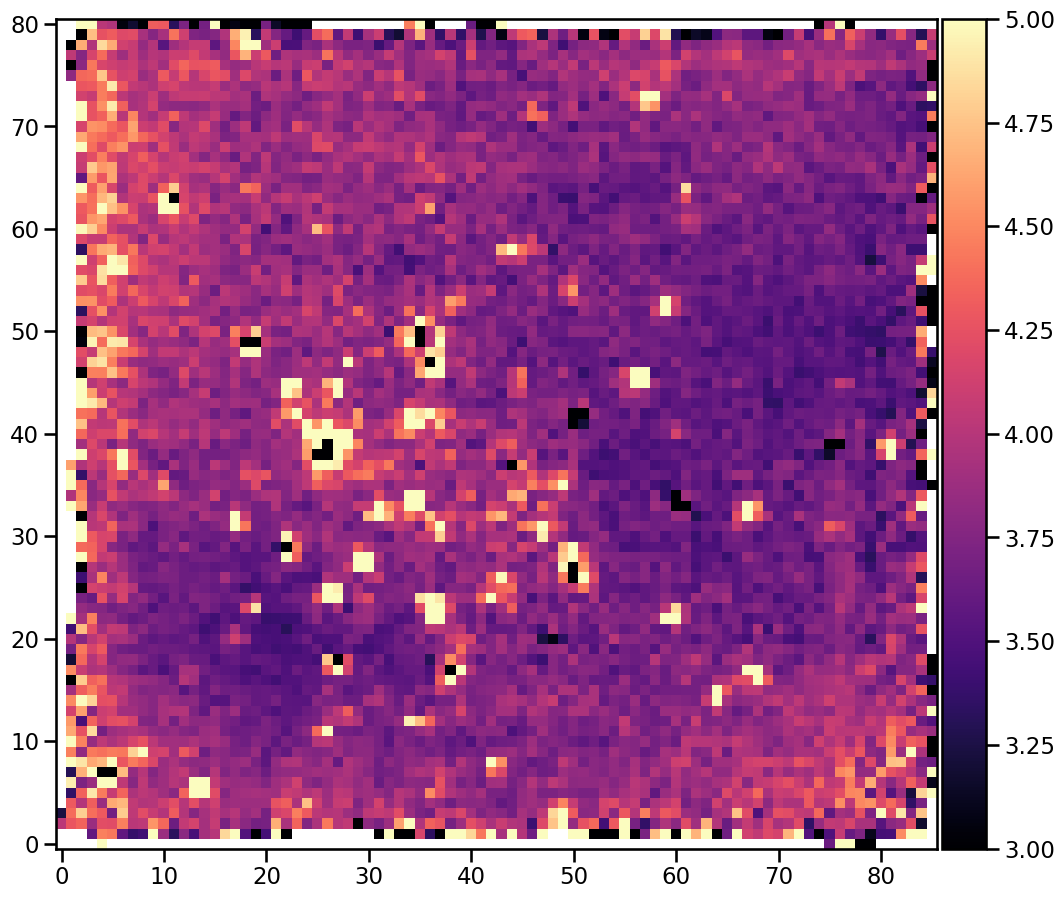

In [96]:
fig, ax = plt.subplots(figsize=(12, 12))
n = 4
(1.012 * im7065.rebin(4) / im7281.rebin(4)).plot(colorbar="v", cmap="magma", vmin=3, vmax=5)

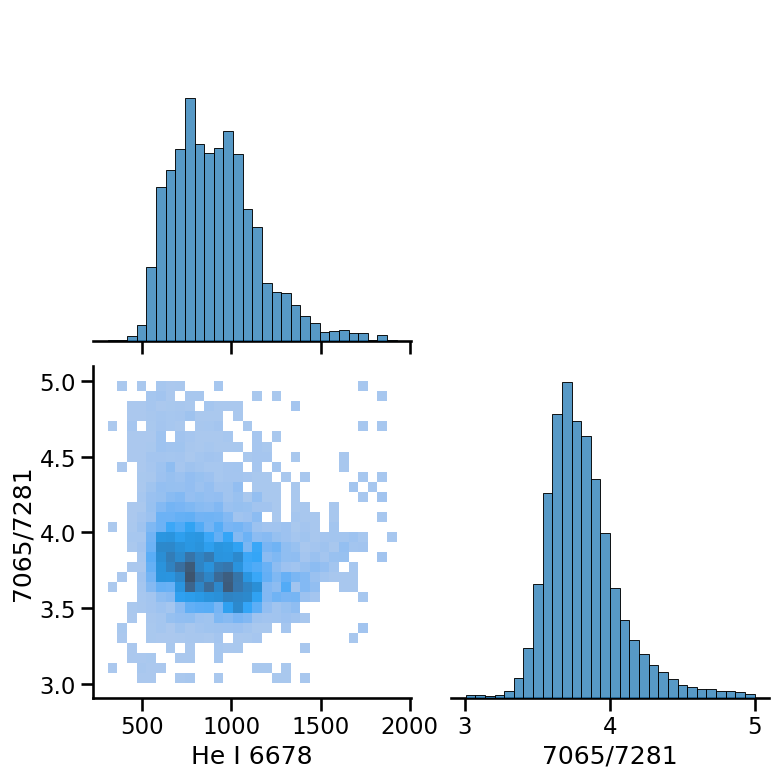

In [144]:
n = 4
x = im6678.rebin(n).data
y = 1.012 * im7065.rebin(n).data / im7281.rebin(n).data 
z = im6678.rebin(n).data
m = (x > 0) & (x < 2000)
m = m & (y > 3) & (y < 5)
m = m & ~im7065.rebin(n).mask & ~im7281.rebin(n).mask
df = pd.DataFrame(
    {
        "He I 6678": x[m],
        "7065/7281": y[m],
    }
)
kws = dict(weights=z[m], bins=30)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=kws,
    diag_kws=kws,
)

In [80]:
np.round(e7065 / e7281, 3)

array([[3.267, 3.327, 3.352, 3.541, 3.717, 3.881],
       [3.292, 3.375, 3.41 , 3.66 , 3.885, 4.089],
       [3.315, 3.419, 3.462, 3.759, 4.02 , 4.251],
       [3.346, 3.476, 3.529, 3.875, 4.169, 4.422]])

### He I T-sensitive ratio



The 7281/6678 ratio depends primarily on T

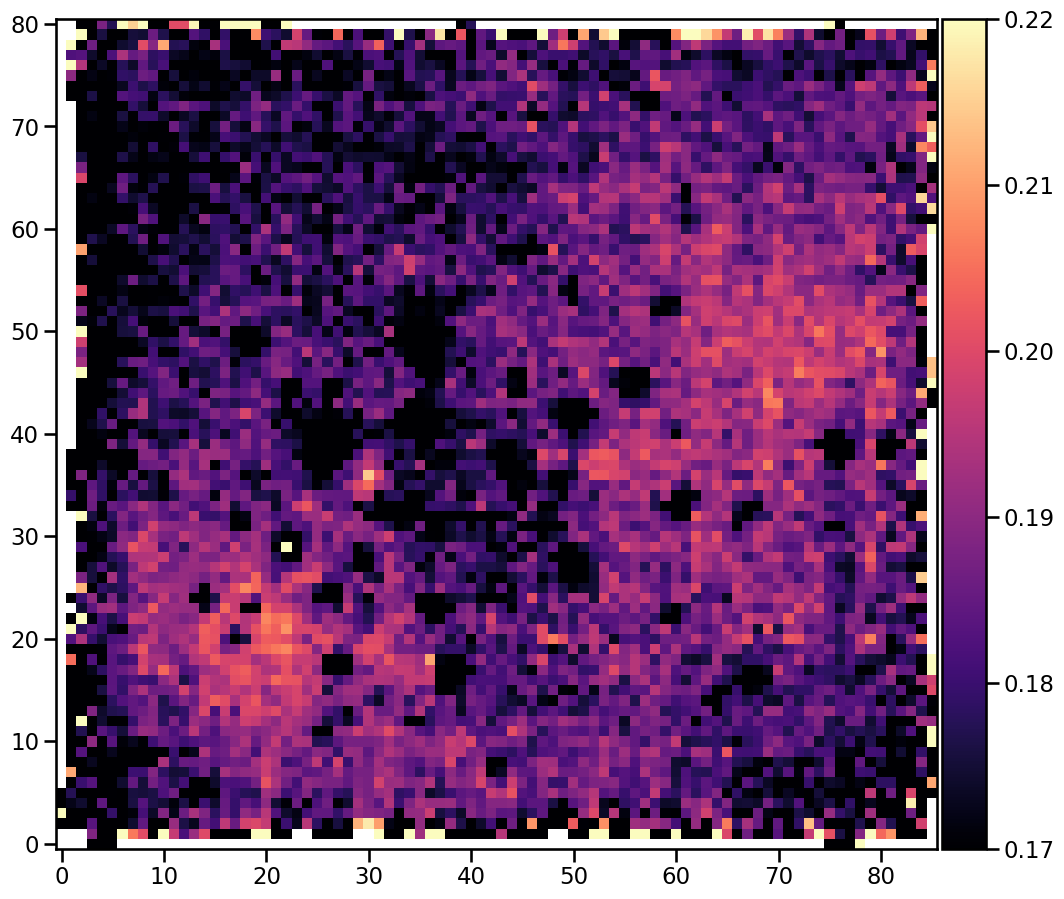

In [98]:
fig, ax = plt.subplots(figsize=(12, 12))
n = 4
(0.96 * im7281.rebin(4) / im6678.rebin(4)).plot(colorbar="v", cmap="magma", vmin=0.17, vmax=0.22)

8283

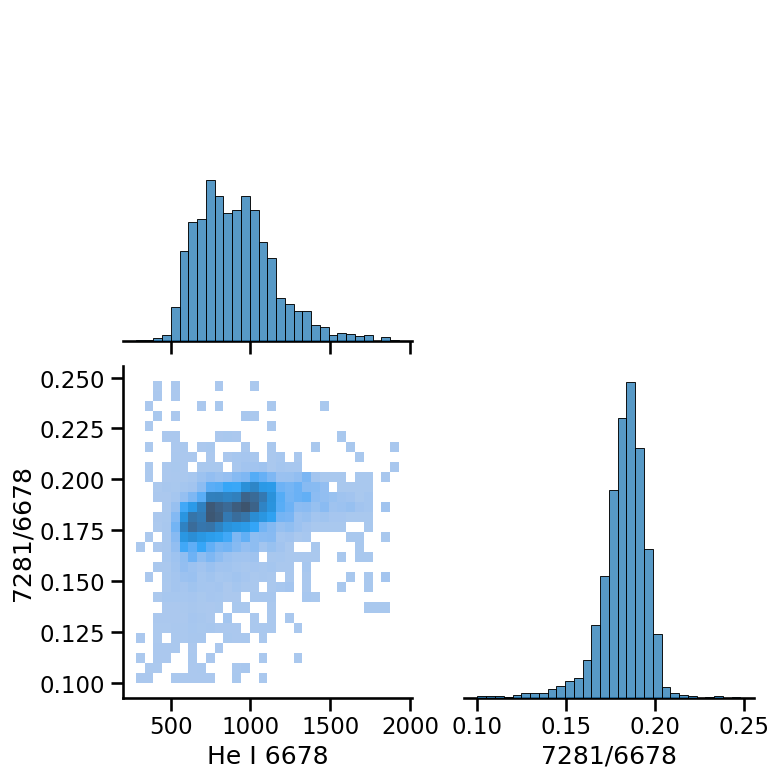

In [143]:
n = 4
x = im6678.rebin(n).data
y = 0.96 * im7281.rebin(n).data / im6678.rebin(n).data
z = im6678.rebin(n).data
m = (x > 0) & (x < 2000)
m = m & (y > 0.1) & (y < 0.25)
m = m & ~im6678.rebin(n).mask & ~im7281.rebin(n).mask
df = pd.DataFrame(
    {
        "He I 6678": x[m],
        "7281/6678": y[m],
    }
)
kws = dict(weights=z[m], bins=30)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=kws,
    diag_kws=kws,
)

In [83]:
np.round(e7281 / e6678, 3)

array([[0.194, 0.196, 0.197, 0.201, 0.205, 0.209],
       [0.212, 0.214, 0.215, 0.219, 0.223, 0.227],
       [0.229, 0.23 , 0.231, 0.234, 0.237, 0.239],
       [0.253, 0.253, 0.253, 0.251, 0.25 , 0.249]])

In [135]:
tems

[11000, 13000, 15000, 18000]

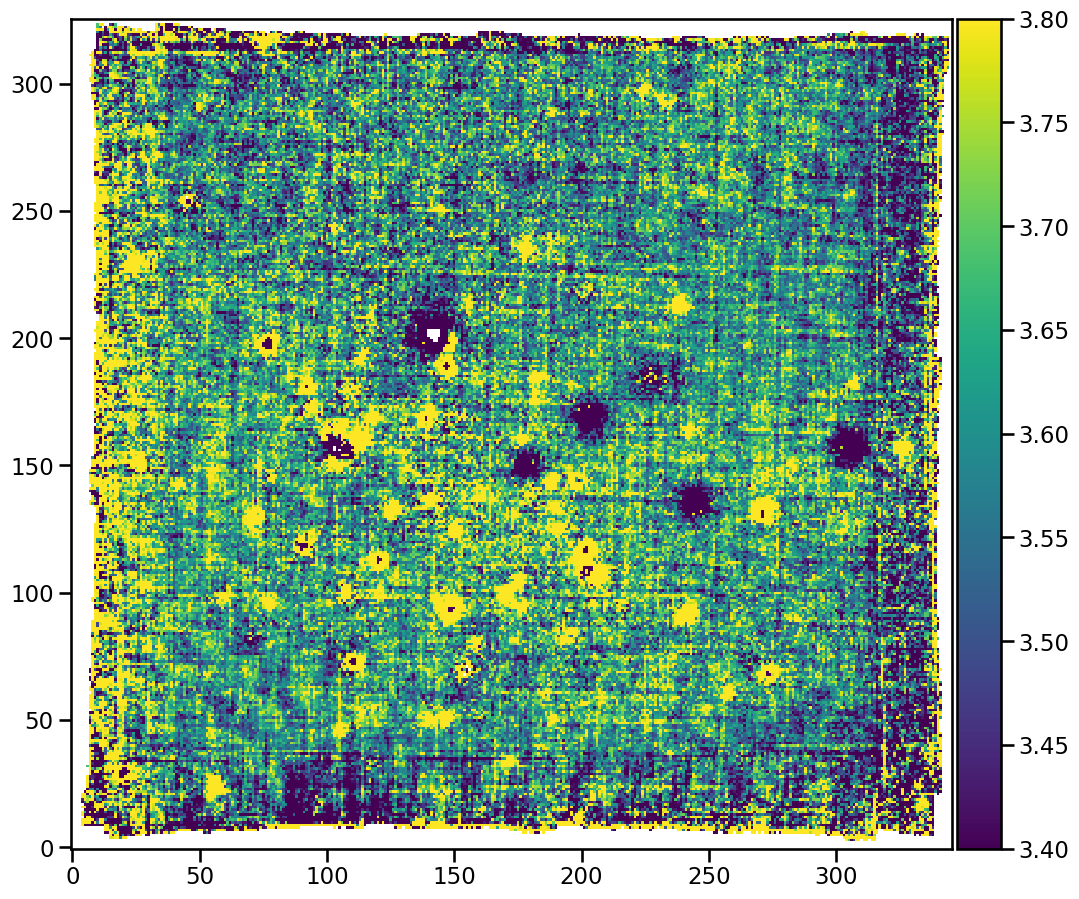

In [21]:
fig, ax = plt.subplots(figsize=(12, 12))
(im5875 / im6678).plot(colorbar="v", cmap="viridis", vmin=3.4, vmax=3.8)

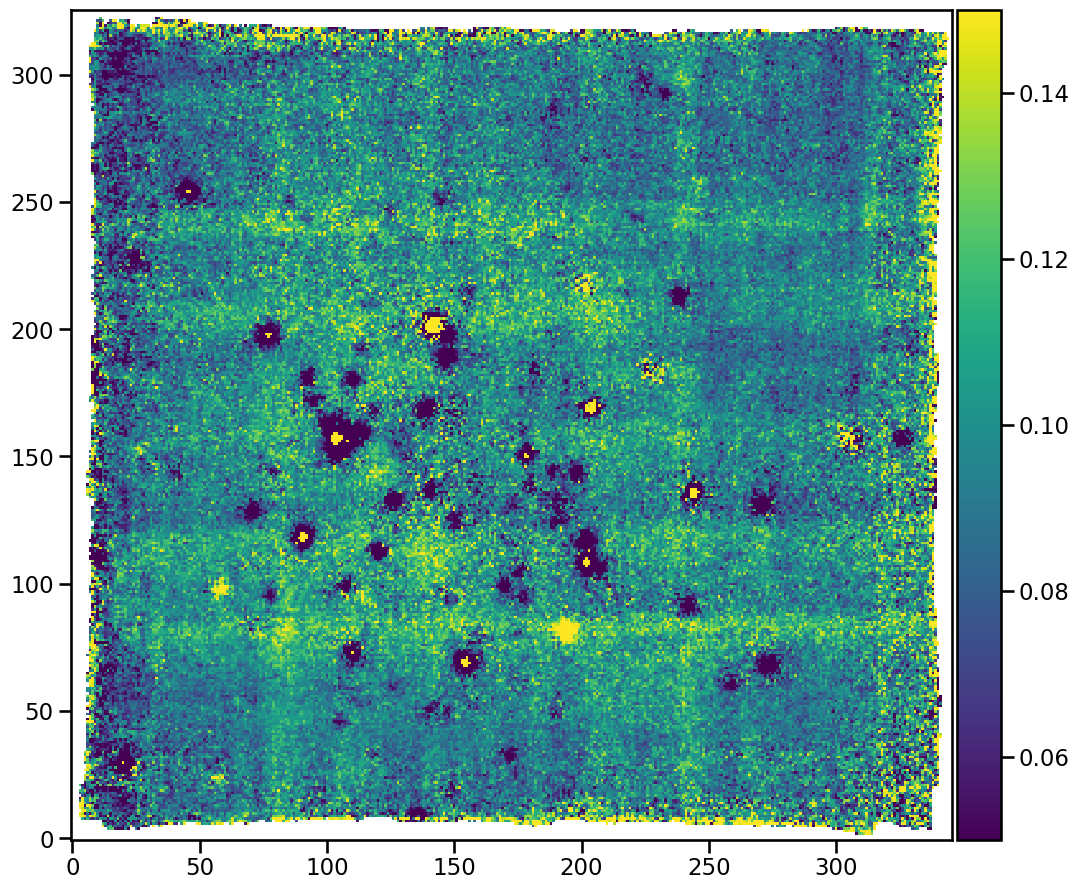

In [22]:
fig, ax = plt.subplots(figsize=(12, 12))
(im5016 / im5875).plot(colorbar="v", cmap="viridis", vmin=0.05, vmax=0.15)

## Calculate He II / Hβ



In [23]:
im4686 = get_image_raw("he-ii-4685-68")

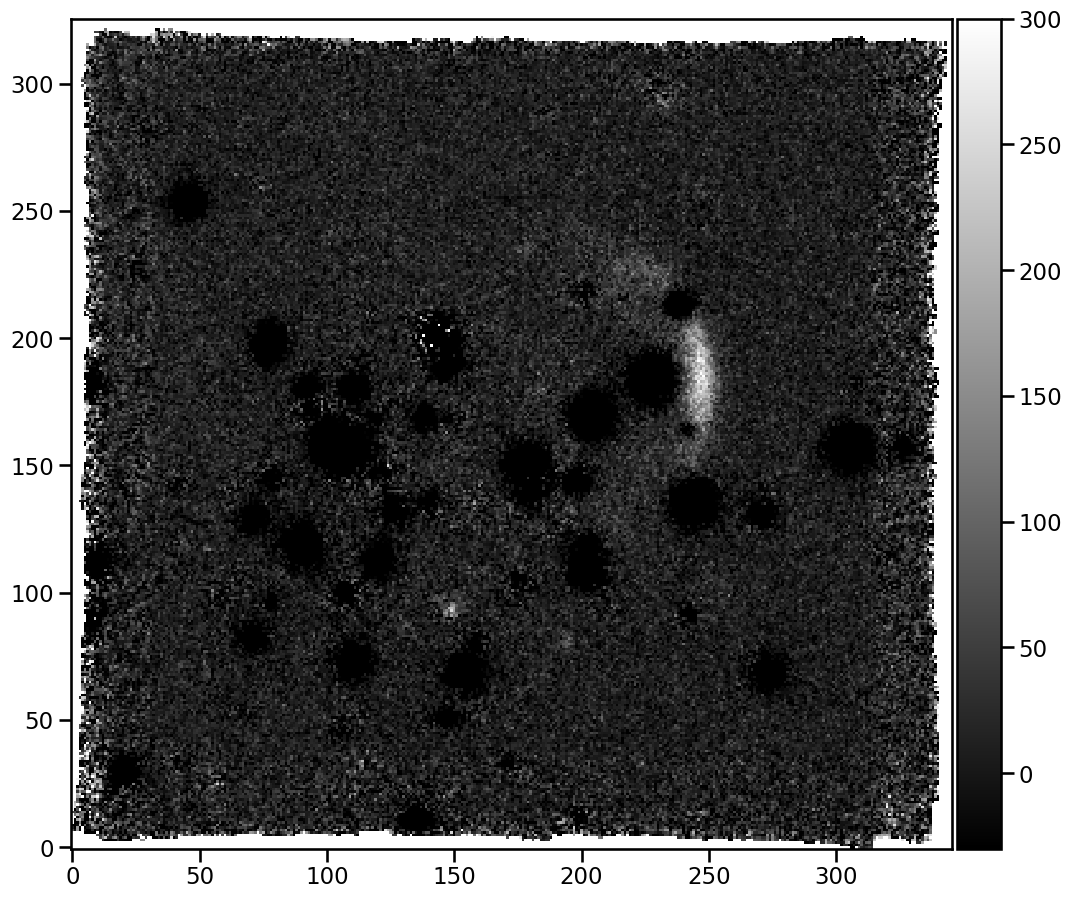

In [24]:
fig, ax = plt.subplots(figsize=(12, 12))
im4686.plot(colorbar="v", cmap="gray", vmin=-30.0, vmax=300)

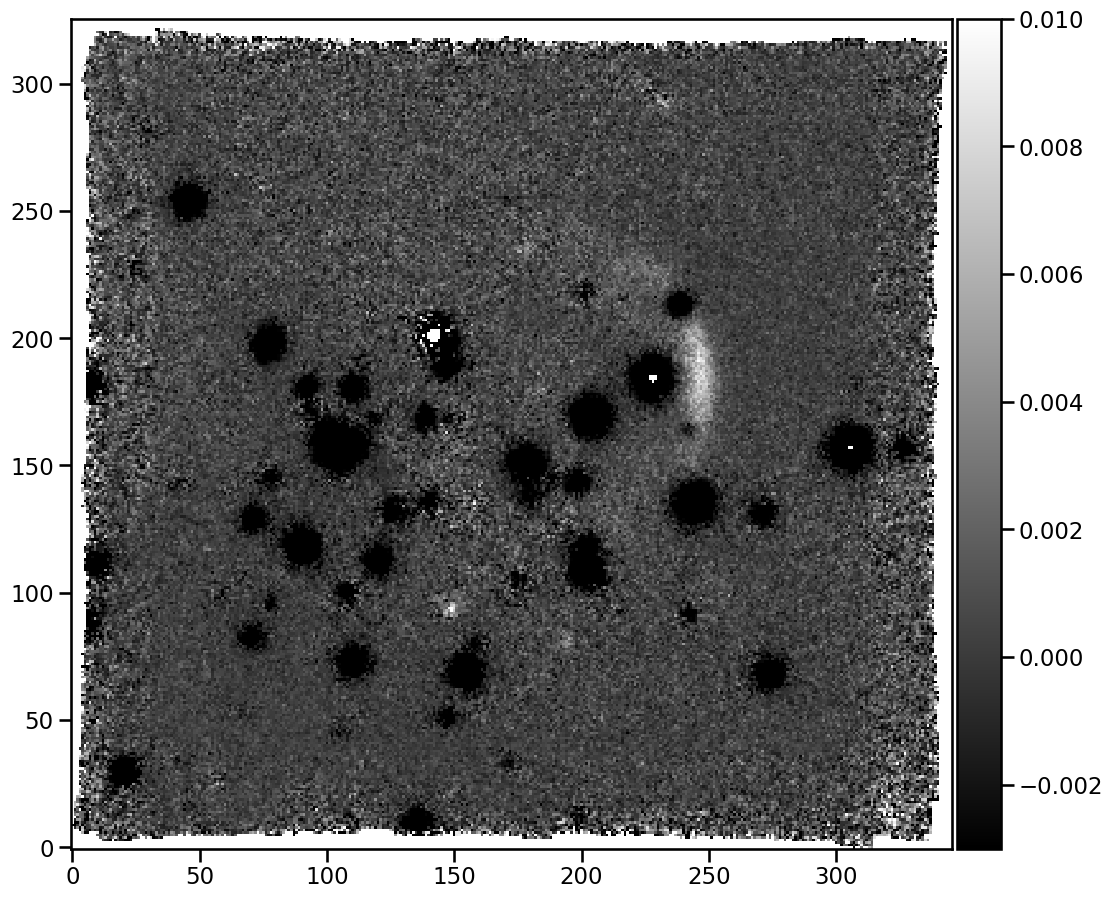

In [25]:
imR_heii_hb = im4686 / imhb

fig, ax = plt.subplots(figsize=(12, 12))
imR_heii_hb.plot(colorbar="v", cmap="gray", vmin=-0.003, vmax=0.01)

Text(0.5, 0.98, 'Correlation between He II / Hβ and He I / Hβ ratios')

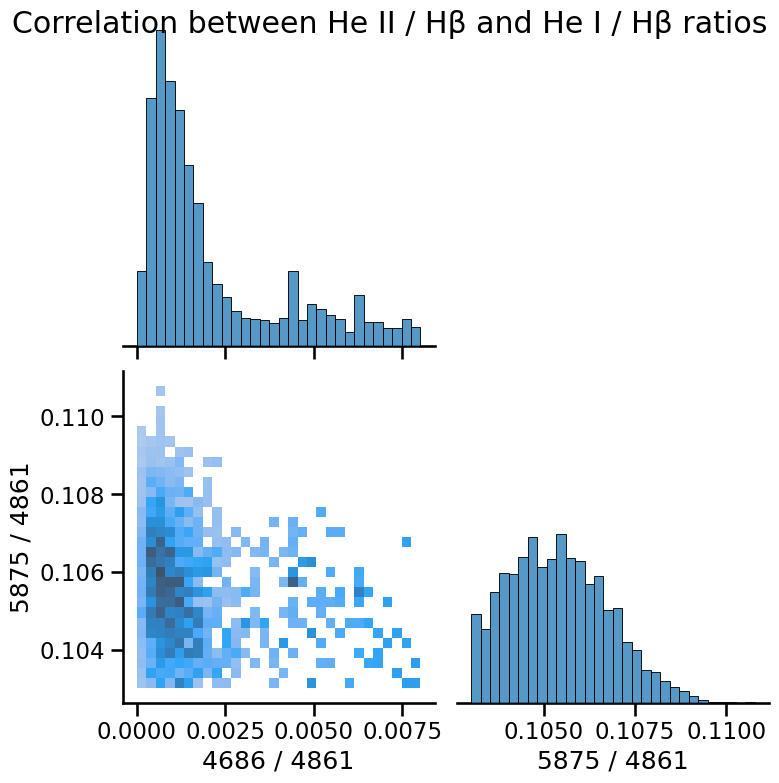

In [148]:
n = 2
xslice, yslice = slice(200, 300), slice(100, 250)
x = imR_heii_hb[yslice, xslice].rebin(n).data
y = (
    imR_hei_hb[yslice, xslice].rebin(n).data
    / red_R_hei_hb[yslice, xslice].rebin(n).data
)
z = im4686[yslice, xslice].rebin(n).data
m = x < 0.03
m = m & (x > 0)
m = m & (y < 0.113)
m = m & (y > 0.103)
m = (
    m
    & ~imR_heii_hb[yslice, xslice].rebin(n).mask
    & ~imR_hei_hb[yslice, xslice].rebin(n).mask
)
df = pd.DataFrame(
    {
        "4686 / 4861": x[m],
        "5875 / 4861": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(weights=z[m], bins=30),
    diag_kws=dict(weights=z[m], bins=30),
)
g.fig.suptitle("Correlation between He II / Hβ and He I / Hβ ratios")

So there is a *tiny* change in 5875/4861 from 0.109 to 0.107 as 4686/4861 increases.

In [27]:
df["high"] = df["4686 / 4861"] > 0.005
df

,4686 / 4861,5875 / 4861,high
0,0.000456,0.104744,False
1,0.000015,0.103495,False
2,0.001615,0.106001,False
3,0.000686,0.105375,False
4,0.000410,0.105410,False
...,...,...,...
2437,0.000456,0.106067,False
2438,0.000342,0.105009,False
2439,0.000306,0.104888,False
2440,0.000108,0.103916,False


<Axes: xlabel='5875 / 4861', ylabel='Probability'>

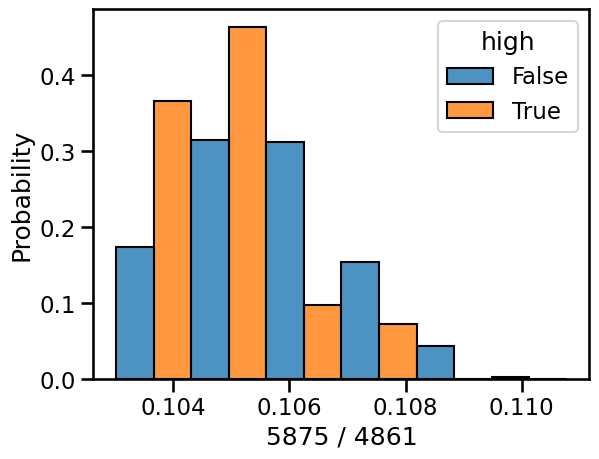

In [28]:
sns.histplot(
    data=df,
    x="5875 / 4861",
    hue="high",
    multiple="dodge",
    shrink=1.0,
    stat="probability",
    common_norm=False,
    alpha=0.8,
    bins=6,
)

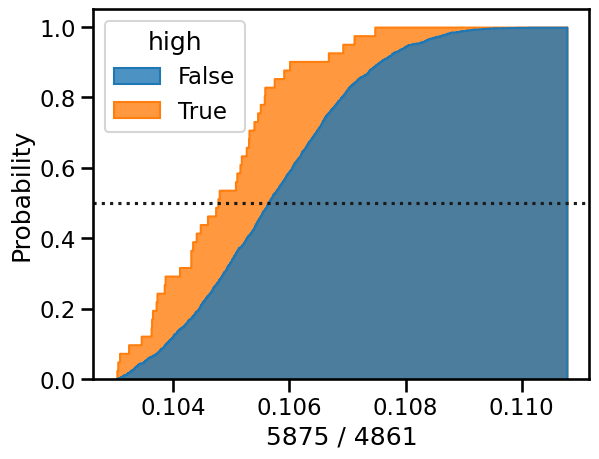

In [29]:
df["high"] = df["4686 / 4861"] > 0.005
sns.histplot(
    data=df,
    x="5875 / 4861",
    hue="high",
    # multiple="dodge",
    shrink=1.0,
    stat="probability",
    cumulative=True,
    common_norm=False,
    alpha=0.8,
    bins=1000,
    element="step",
).axhline(0.5, linestyle="dotted", color="k")

Try to remove the pattern noise

In [30]:
imR_heii_hb_fake = imR_heii_hb.copy()
m = imR_heii_hb_fake.data > 0.01
imR_heii_hb_fake.data[m] = np.nan
vv = np.nanmedian(imR_heii_hb_fake.data, axis=0, keepdims=True)
hh = np.nanmedian(imR_heii_hb_fake.data, axis=1, keepdims=True)
imR_heii_hb_fake.data = vv + hh
imR_heii_hb_fake.data -= np.nanmedian(vv + hh)
imR_heii_hb_c = imR_heii_hb.copy()
imR_heii_hb_c.data -= imR_heii_hb_fake.data

/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_74888/1126909528.py:4: RuntimeWarning: All-NaN slice encountered
  vv = np.nanmedian(imR_heii_hb_fake.data, axis=0, keepdims=True)
/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_74888/1126909528.py:5: RuntimeWarning: All-NaN slice encountered
  hh = np.nanmedian(imR_heii_hb_fake.data, axis=1, keepdims=True)


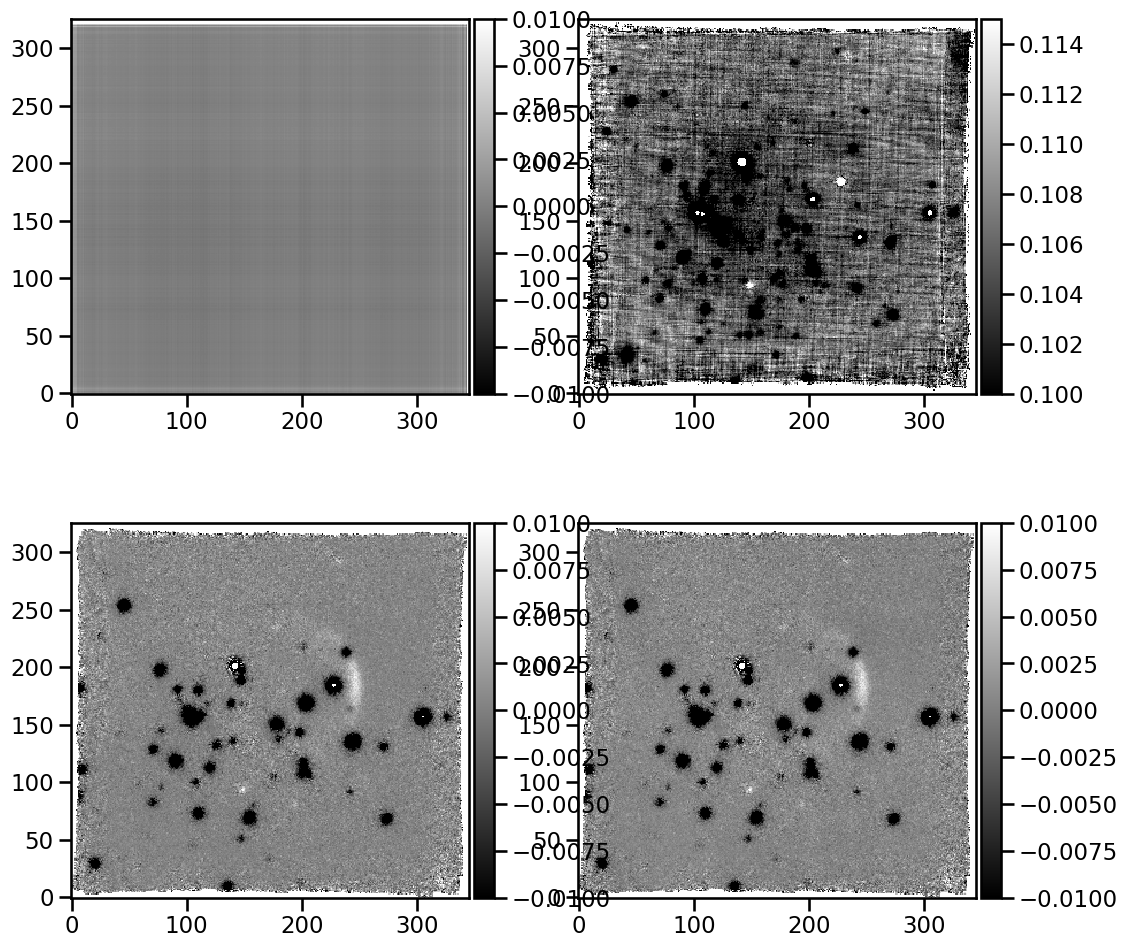

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
imR_heii_hb_fake.plot(ax=axes[0, 0], colorbar="v", cmap="gray", vmin=-0.01, vmax=0.01)
(imR_hei_hb / red_R_hei_hb).plot(
    ax=axes[0, 1], colorbar="v", cmap="gray", vmin=0.1, vmax=0.115
)
imR_heii_hb.plot(ax=axes[1, 0], colorbar="v", cmap="gray", vmin=-0.01, vmax=0.01)
imR_heii_hb_c.plot(ax=axes[1, 1], colorbar="v", cmap="gray", vmin=-0.01, vmax=0.01)

Text(0.5, 0.98, 'Correlation between He II / Hβ and He I / Hβ ratios')

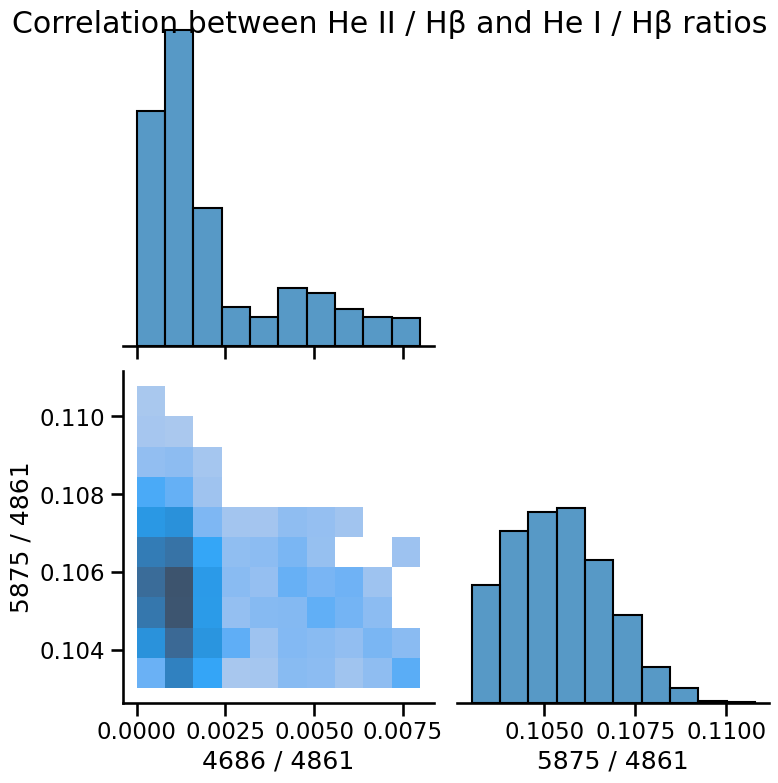

In [32]:
n = 2
xslice, yslice = slice(200, 300), slice(100, 250)
# xslice, yslice = slice(230, 300), slice(130, 220)
x = imR_heii_hb_c[yslice, xslice].rebin(n).data
y = (
    imR_hei_hb[yslice, xslice].rebin(n).data
    / red_R_hei_hb[yslice, xslice].rebin(n).data
)
z = im4686[yslice, xslice].rebin(n).data
m = x < 0.03
m = m & (x > 0)
m = m & (y < 0.113)
m = m & (y > 0.103)
m = (
    m
    & ~imR_heii_hb[yslice, xslice].rebin(n).mask
    & ~imR_hei_hb[yslice, xslice].rebin(n).mask
)
df = pd.DataFrame(
    {
        "4686 / 4861": x[m],
        "5875 / 4861": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(weights=z[m], bins=10),
    diag_kws=dict(weights=z[m], bins=10),
)
g.fig.suptitle("Correlation between He II / Hβ and He I / Hβ ratios")

<Axes: xlabel='5875 / 4861', ylabel='Probability'>

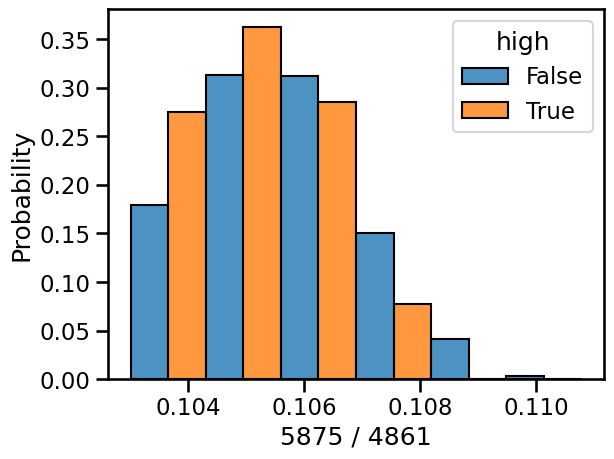

In [33]:
df["high"] = df["4686 / 4861"] > 0.003
sns.histplot(
    data=df,
    x="5875 / 4861",
    hue="high",
    multiple="dodge",
    shrink=1.0,
    stat="probability",
    common_norm=False,
    alpha=0.8,
    bins=6,
)

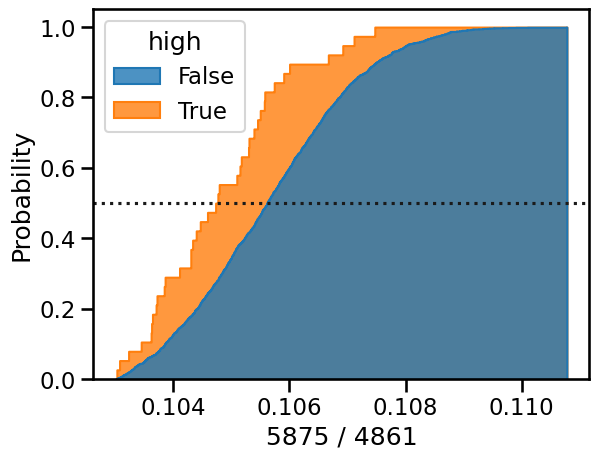

In [34]:
df["high"] = df["4686 / 4861"] > 0.005
sns.histplot(
    data=df,
    x="5875 / 4861",
    hue="high",
    # multiple="dodge",
    shrink=1.0,
    stat="probability",
    cumulative=True,
    common_norm=False,
    alpha=0.8,
    bins=1000,
    element="step",
).axhline(0.5, linestyle="dotted", color="k")

So, the depatterning improved the map but did not help with the statistics.

